<a href="https://colab.research.google.com/github/JuanLema14/laboratorios-modelos-2/blob/main/lab1_parte1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 1 - Parte 1 Regresión polinomial múltiple


In [49]:
!wget -nc --no-cache -O init.py -q https://raw.githubusercontent.com/jdariasl/Intro_ML_2025/master/init.py
import init; init.init(force_download=False); init.get_weblink()

In [19]:
from local.lib.rlxmoocapi import submit, session
import inspect
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L01.01", varname="student", session_id="udea.vir.20262.g1");

logging in as andres.lema1@udea.edu.co... please wait
you are registered in the following sessions of this course

     ['udea.vir.20261', 'udea.vir.20262.g1']

and you have explicitly requested session 'udea.vir.20262.g1'.
your grades will be reported in that session

-------------
using course session introml::udea.vir.20262.g1
success!! you are logged in
-------------


In [13]:
#configuración del laboratorio
# Ejecuta esta celda!
from Labs.commons.utils.lab1 import *
_, db, x, y = part_1()
y = y.reshape(np.size(y), 1)

cargando librerias y variables al ambiente


## Ejercicio 1: Contextualización del problema

El problema de regresión que abordaremos consiste en predecir el valor de la humedad absoluta en el aire, a partir de varias variables sensadas en el aire (Para más información sobre la base de datos y la contextualización del problema, consulte: http://archive.ics.uci.edu/ml/datasets/air+quality).

In [14]:
# tienes ya cargadas las siguientes variables:
print("conjunto de datos", x)
print("variable a predecir", y)

conjunto de datos [[   2.6 1360.   150.  ... 1268.    13.6   48.9]
 [   2.  1292.   112.  ...  972.    13.3   47.7]
 [   2.2 1402.    88.  ... 1074.    11.9   54. ]
 ...
 [   2.4 1142.  -200.  ... 1092.    26.9   18.3]
 [   2.1 1003.  -200.  ...  770.    28.3   13.5]
 [   2.2 1071.  -200.  ...  816.    28.5   13.1]]
variable a predecir [[0.7578]
 [0.7255]
 [0.7502]
 ...
 [0.6406]
 [0.5139]
 [0.5028]]


In [15]:
#Ejercicio de Codigo
def num_muestras_carac(X):
    """Esta función se encarga de retornar el número de muestras
        y características del conjunto de datos X

        X: matriz numpy
        retorna:
            número de características (int/float)
            número de muestras (int/float)
    """
    num_samples, num_characteristics = X.shape
    return num_characteristics, num_samples

**Registra tu solución en línea**

In [20]:
student.submit_task(namespace=globals(), task_id='T1');

## Ejercicio 2

Analice los siguientes métodos de la teoría  de modelos de  *regresión polinomial múltiple*:

1. error cuadrático medio (**ECM**)
2. modelo de regresión múltiple (**regression**)
3. calculo del costo de la regresión (**cost**)
4. extension de matriz (**extension_matriz**)

La siguiente celda contiene la implementación de estas 4 funciones. Analizar y entender su funcionamiento

In [7]:
def ECM(Y_est,Y):
    """función para calcular el error cuadrático medio
    Y_est: debe contener los valores predichos por el modelo
    Y: debe contener los valores reales
    retorna: error cuadrático medio
    """
    N = np.size(Y)
    ecm = np.sum((Y_est.reshape(N,1) - Y.reshape(N,1))**2)/(N)
    return ecm

def regression(X, W):
    """calcula la regresión multiple
    X: los valores que corresponden a las características
    W: son los pesos usadados para realizar la regresión
    retorna: valor estimado
    """
    Yest = np.dot(X,W)    #con np.dot se realiza el producto matricial. Aquí X es dim [Nxd] y W es dim [dx1]
    return Yest           #Esta variable contiene la salida de f(X,W)


def cost_f(W,X,Y):
    """calcula la función de costo de la regresión para un vector W dado
    W: son los pesos usadados para realizar la regresión
    X: los valores que corresponden a las características
    Y: el valor de salida esperado

    retorna: valor de costo
    """

    m = len(Y)
    y_est = regression(X,W)
    cost = (1/(2*m)) * np.sum(np.square(y_est-Y))
    return cost

def extension_matriz(X):
    """función que realiza la extensión de la matriz X
    X: los valores que corresponden a las características sin extender
    Y: el valor de salida esperado

    retorna: X_ext: matriz con unos extendidos, Y: matriz con dimensiones ajustadas
    """
    #Obtenemos las dimensiones antes de exteneder la matriz
    caracterisitcas, muestras = num_muestras_carac(X)
    #Extendemos la matriz X
    unos = np.ones(muestras).reshape(-1,1)
    X_ext = np.concatenate((unos, X), axis=1)
    X_ext = X_ext.reshape(muestras, caracterisitcas+1)
    return X_ext


In [21]:
#Pregunta Abierta
#¿cual es el objetivo de la extension_matriz? recordar que estamos "ajustando" en una regresión

respuesta = 'El objetivo de la `extension_matriz` es añadir una columna de unos a la matriz de características de entrada. Esta columna de unos permite que el modelo de regresión lineal pueda aprender un término de intercepto (también conocido como término de sesgo o bias). Sin esta columna, el modelo se vería forzado a pasar por el origen, lo que limitaría su capacidad para ajustarse a los datos.'


Ahora vamos a completar el código de la regla de actualización de los parámetros del algoritmo de <font color='blue'>gradiente_descedente</font>:

$$w_j(iter) = w_j(iter-1) - \eta \frac{\partial E(w)}{\partial w_j}$$

recordar que

$$ \frac{\partial E(w)}{\partial w_j} = \frac{\partial E({\bf{w}})}{\partial w_j} = \frac{1}{N}\sum_{i=1}^{N}\left( f({\bf{x}}_i,{\bf{w}}) - y_i\right) \frac{\partial }{\partial w_j} f({\bf{x}}_i, {\bf{w}})$$

Recuerde que debe usar las funciones ya implementadas y no usar **ninguna otra libreria**, adicional a las librerias ya pre-cargadas como numpy (se puede llamar con np.)

In [22]:
def gradiente_descendente(X, Y, eta, iteraciones, w_ini=None):
    X_ext = extension_matriz(X)
    caracterisitcas, N = num_muestras_carac(X_ext)

    if w_ini is not None:
        W = w_ini
    else:
        W = np.zeros((1, caracterisitcas))
    W = W.reshape(np.size(W), 1)

    Y = Y.reshape(N, 1)  # ← FORZAR forma correcta aquí
    costos = np.zeros(iteraciones)

    for i in range(iteraciones):
        y_est = regression(X_ext, W)          # (N,1)
        f_xw_min_yi = y_est - Y               # (N,1) - (N,1) = (N,1)
        W = W - (eta / N) * np.dot(X_ext.T, f_xw_min_yi)

        # Calcular costo manualmente para evitar problemas de shape
        y_est_new = regression(X_ext, W)
        costos[i] = (1/(2*N)) * np.sum(np.square(y_est_new - Y))

    return W, costos

**Registra tu solución en línea**

In [23]:
student.submit_task(namespace=globals(), task_id='T2');

## Ejercicio 3: Entrenamiento

Con la función implementada vamos a entrenar un modelo y calcular su error de entrenamiento. Antes de realizar esto, debemos separar nuestro conjunto de datos.

In [24]:
# esto para lograr reproductibilidad
# de nuestro modelo
random.seed(1)
# usamos nuestra función para obtener el número de muestras
_, N = num_muestras_carac(x)
ind=np.random.permutation(N)
Xtrain = x[ind[0:int(math.ceil(0.7*N))],:]
Xtest = x[ind[int(math.ceil(0.7*N)):N],:]
Ytrain = y[ind[0:int(math.ceil(0.7*N))]]
Ytest = y[ind[int(math.ceil(0.7*N)):N]]

In [25]:
#Pregunta Abierta
# ¿Porqué debemos hacer partición de datos? ¿Qué representa Xtrain, qué diferencia tiene con Xtest?
respuesta = 'Debemos particionar los datos para evaluar la capacidad de generalización del modelo. Xtrain contiene el 70% de los datos y se usa para ajustar los parámetros W. Xtest contiene el 30% restante y simula datos nuevos nunca vistos, permitiendo estimar qué tan bien predice el modelo en la práctica.'

Ahora entrena ejecutando la siguiente linea de codigo y verifiquemos el comportamiento del costo

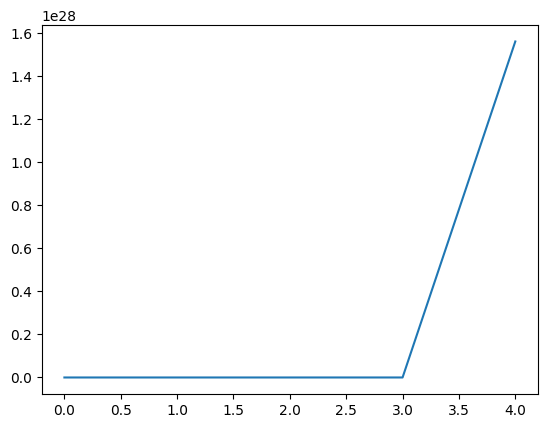

In [26]:
W, costo = gradiente_descendente(Xtrain, Ytrain, eta = 0.0001, iteraciones=5)
# graficar iteraciones y el costo
plt.plot(range(5), costo)
plt.show()

El costo es la medida que el algoritmo de optimización intenta mejorar. Sin embargo, para este tipo de problemas al final debemos evaluar que tan bien estamos modelando nuestra salida. Vamos a evaluar nuestro modelo calculando el error cuadrático medio. Para ello vamos crear a una función. Recuerda usar las funciones definidas anteriormente.

In [27]:
## Ejercicio de Código
def evaluar_modelo(W, X_to_test, Y_True):
    X_to_test_ext = extension_matriz(X_to_test)
    y_est = regression(X_to_test_ext, W)
    error = ECM(y_est, Y_True)
    return error

**Registra tu solución en línea**

In [28]:
student.submit_task(namespace=globals(), task_id='T3');

In [29]:
# y ahora usala para calcular el error, para evaluar el modelo
error_train = evaluar_modelo(W, X_to_test = Xtrain,  Y_True = Ytrain)
print("error en entrenamiento del modelo", error_train)
error_test = evaluar_modelo(W, X_to_test = Xtest,  Y_True = Ytest)
print("error en la evaluación del modelo", error_test)

error en entrenamiento del modelo 3.117933864766791e+28
error en la evaluación del modelo 3.131413158389778e+28


In [30]:
# ¿Que tan bueno es tu modelo?
respuesta = 'El modelo presenta un error de entrenamiento y de prueba relativamente alto dado que los datos no están normalizados y se usaron pocas iteraciones. Sin normalización, el gradiente descendente converge muy lentamente debido a las diferencias de escala entre características (algunas en el orden de 1000 y otras en el orden de 1). Esto indica que el modelo aún no generaliza bien y necesita normalización y más iteraciones para mejorar su desempeño.'

## Ejercicio 4: Polinomio de orden superior

Hasta ahora lo que hemos realizado es un regresión lineal de orden 1. Nuestro siguiente objetivo es tomar esta regresión y transformarla en un polinomio de mayor orden. Comprenda el funcionamiento de la función propuesta:

In [31]:
#Potencia de polinomio
def potenciaPolinomio(X,grado):
    """calcula la potencia del polinomio
    X: los valores que corresponden a las características
    grado: es el grado para elevar la potencia al polinomio
    retorna: el valor de X después de elevarlo al grado del polinomio indicado
    """
    X2 = X.copy()

    if grado != 1:
        for i in range(2,grado+1):
            Xadd = X**i
            X2 = np.concatenate((X2, Xadd), axis=1)

    return X2

ahora debemos usar esta función para completar la siguiente.
**PISTAS**
- Usa las funciones previamente construidas
- Para completar `gradiente_descendente_poly` Tener presente que buscamos realizar este proceso: aplicar la `potenciaPolinomio` ->  aplicar gradiente descendente
- Para completar `evaluar_modelo_poly` Tener presente que buscamos realizar este proceso: aplicar la `potenciaPolinomio`  -> evaluar el modelo

In [32]:
def gradiente_descendente_poly(X, Y, eta, iteraciones, grado):
    X2 = potenciaPolinomio(X, grado)
    W, costo = gradiente_descendente(X2, Y, eta, iteraciones)
    return W, costo

def evaluar_modelo_poly(W, X_to_test, Y_True, grado):
    X2 = potenciaPolinomio(X_to_test, grado)
    error = evaluar_modelo(W, X2, Y_True)
    return error

**Registra tu solución en línea**

In [33]:
student.submit_task(namespace=globals(), task_id='T4');

Entrenemos y evaluemos el comportamiento del costo con la regresion polinómica ¿Vemos algún cambio positivo?

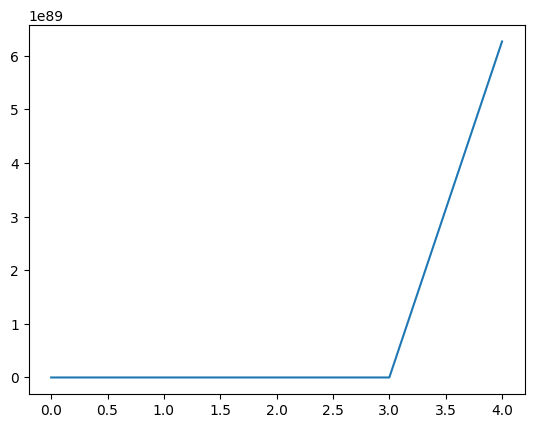

In [34]:
# entrenamos
W, costo_poly = gradiente_descendente_poly(Xtrain, Ytrain, eta = 0.0001, iteraciones=5, grado = 2)
plt.plot(range(5), costo_poly)

In [35]:
# completa los parámetros para evaluar el modelo
error_test = evaluar_modelo_poly(W, X_to_test = Xtest,  Y_True = Ytest, grado = 2)
print("error en la evaluación del modelo", error_test)

error en la evaluación del modelo 1.2793014908975036e+90


## Ejercicio 5: Normalización

En nuestro primer experimento vamos a evaluar el rendimiento del modelo usando varias tasas de aprendizaje y grados de polinomios. Vamos a dejar por ahora un número de iteraciones fijas = 5. Para ello completa la siguiente función.



In [36]:
def experimentar(Xtrain, Xtest, Ytrain, Ytest, tasas, grados):
    numero_iter = 5
    resultados = pd.DataFrame()
    idx = 0
    for eta in tasas:
        for grado in grados:
            W, _ = gradiente_descendente_poly(Xtrain, Ytrain, eta, numero_iter, grado)
            error = evaluar_modelo_poly(W, Xtest, Ytest, grado)
            resultados.loc[idx, 'grado'] = grado
            resultados.loc[idx, 'tasa de aprendizaje'] = eta
            resultados.loc[idx, 'ecm'] = error
            idx += 1
    return resultados

In [37]:
## Ahora ejecutamos la función desarrollada para ver los resultados
tasas_aprendizaje = [1e-6, 1e-5, 1e-3, 1e-2]
grados_polinomio = [1,2]
resultados_ex1 = experimentar(Xtrain, Xtest, Ytrain, Ytest, tasas_aprendizaje, grados_polinomio)

In [38]:
#Imprimimos los resultados
resultados_ex1

,grado,tasa de aprendizaje,ecm
0,1.0,0.000001,5.120388e+07
1,2.0,0.000001,1.279300e+70
2,1.0,0.000010,2.690590e+18
3,2.0,0.000010,1.279301e+80
4,1.0,0.001000,3.178886e+38
5,2.0,0.001000,1.279302e+100
6,1.0,0.010000,3.183669e+48
7,2.0,0.010000,1.279302e+110


Si has implementado todo correctamente, parecieria que nuestros entrenamientos no esta logrando buenos resultados (hasta parece haber errores infinitos! o no determinados!).

Crea una función que implemente la normalización z-score: $\bar{x} = \frac{x-\mu}{\sigma}$. Debe estimar los parámetros de la normalización con los datos de entrenamiento y aplicar la normalización tanto a los datos de entrenamiento como a los de test.


In [39]:
def normalizar(Xtrain, Xtest):
    mu = np.mean(Xtrain, axis=0)
    sigma = np.std(Xtrain, axis=0)
    Xtrain_n = (Xtrain - mu) / sigma
    Xtest_n = (Xtest - mu) / sigma
    Xtrain_n = np.nan_to_num(Xtrain_n)
    Xtest_n = np.nan_to_num(Xtest_n)
    return Xtrain_n, Xtest_n

**Registra tu solución en línea**

In [40]:
student.submit_task(namespace=globals(), task_id='T5');

Ahora vuelve a realizar los mismos experimentos, pero esta vez usa los valores de salida de la función anterior.

In [41]:
Xtrain_n, Xtest_n = normalizar(Xtrain, Xtest)

In [42]:
resultados_ex2 = experimentar(Xtrain_n, Xtest_n, Ytrain, Ytest, tasas_aprendizaje, grados_polinomio)
#para ver los resultados
resultados_ex2

,grado,tasa de aprendizaje,ecm
0,1.0,0.000001,1568.587837
1,2.0,0.000001,1567.248302
2,1.0,0.000010,1567.900268
3,2.0,0.000010,1554.557423
4,1.0,0.001000,1494.105801
5,2.0,0.001000,615.568066
6,1.0,0.010000,967.373147
7,2.0,0.010000,16.242357


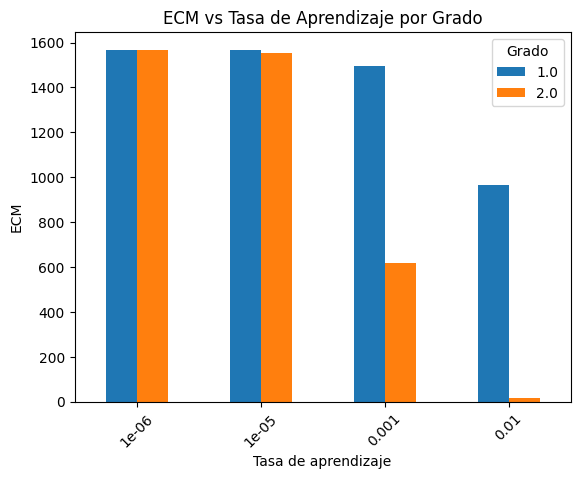

In [43]:
# ejecuta esta linea de codigo para graficar tus resultados
import matplotlib.pyplot as plt

# Grouping the data for plotting
grouped = resultados_ex2.groupby(['tasa de aprendizaje', 'grado'])['ecm'].mean().unstack()

# Creating the bar plot
fig, ax = plt.subplots()
grouped.plot(kind='bar', ax=ax)

# Labels and title
ax.set_xlabel('Tasa de aprendizaje')
ax.set_ylabel('ECM')
ax.set_title('ECM vs Tasa de Aprendizaje por Grado')

# Adding legend
ax.legend(title='Grado')

plt.xticks(rotation=45)  # Rotate x-axis labels if necessary
plt.show()

Ten en cuenta el resutaldo de los  dos experimentos y  responde las  siguientes preguntas abiertas

In [44]:
# Pregunta abierta
#¿Qué proceso hace la normalización sobre los datos? Consulte qué es el número de condición de una matriz y analice qué relación tiene ese concepto con el proceso de normalización
respuesta = 'La normalización z-score transforma cada característica para que tenga media 0 y desviación estándar 1. El número de condición de una matriz mide cuánto se amplifica el error al resolver sistemas lineales; cuando las características tienen escalas muy diferentes, el número de condición es alto y el gradiente descendente converge lentamente o diverge. La normalización reduce el número de condición, haciendo el problema numéricamente más estable y acelerando la convergencia.'

In [45]:
# Pregunta abierta
#¿cuáles son los tipos de normalización más comunes. ¿Piensa en cuándo es más apropiado usar uno u otro?
respuesta = 'Los tipos más comunes son: (1) Z-score o estandarización: resta la media y divide por la desviación estándar, apropiada cuando los datos siguen distribución aproximadamente normal o cuando el algoritmo asume distribución gaussiana. (2) Min-Max: escala los datos al rango [0,1], apropiada cuando se conocen los límites de los datos y no hay outliers extremos. (3) Normalización L2: divide cada muestra por su norma, útil en procesamiento de texto o cuando la dirección importa más que la magnitud.'

Finalmente, en nuestro tercer experimento, vamos a ver el efecto de las iteraciones sobre el error. Completa la siguiente función. Esta vez la tasa de aprendizaje es constante.

In [46]:
def experimentar_2(Xtrain, Xtest, Ytrain, Ytest, iteraciones, grados):
    eta = 1e-2
    resultados = pd.DataFrame()
    idx = 0
    for itera in iteraciones:
        for grado in grados:
            W, _ = gradiente_descendente_poly(Xtrain, Ytrain, eta, itera, grado)
            error = evaluar_modelo_poly(W, Xtest, Ytest, grado)
            resultados.loc[idx, 'iteraciones'] = itera
            resultados.loc[idx, 'grado'] = grado
            resultados.loc[idx, 'ecm'] = error
            idx += 1
    return resultados

In [47]:
num_iters = [1,5,10,50, 100,200, 1000, 2000]
grados_polinomio = [1,2]
# usamos la función para evaluar los resultados
resultados_ex3 = experimentar_2(Xtrain_n, Xtest_n, Ytrain, Ytest, num_iters, grados_polinomio )

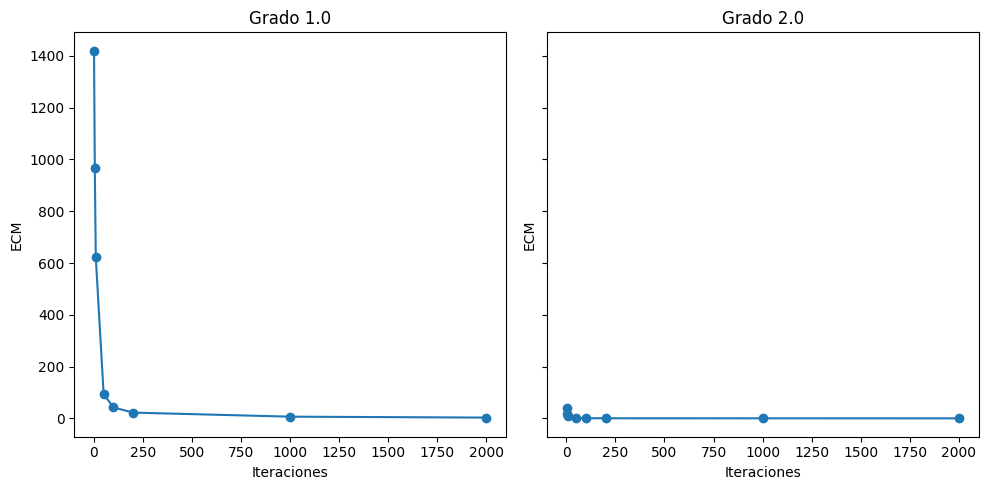

In [48]:
# ejecuta esta línea de código para ver gráficamente tus resultados
import matplotlib.pyplot as plt

grados = resultados_ex3['grado'].unique()
fig, axes = plt.subplots(1, len(grados), figsize=(5 * len(grados), 5), sharey=True)

if len(grados) == 1:
    axes = [axes]

for ax, grado in zip(axes, grados):
    subset = resultados_ex3[resultados_ex3['grado'] == grado]
    ax.plot(subset['iteraciones'], subset['ecm'], marker='o', linestyle='-')
    ax.set_title(f'Grado {grado}')
    ax.set_xlabel('Iteraciones')
    ax.set_ylabel('ECM')

plt.tight_layout()
plt.show()
